# Multi-Asset Scenario Engine for Joint Equity–Rates Horizon Repricing (v4)

This notebook pushes the project beyond the original course-style framing into a **research / GitHub-oriented scenario engine** for **joint scenario generation under the physical measure** and **horizon repricing** of equity and rates instruments.

## What is new in v4

Relative to v3.1, the engine is extended in three concrete directions:

1. **Equity-premium generator upgrade**  
   - the equity block is no longer only a latent tech-basket factor;  
   - it now supports an **explicit external market ERP proxy** (here: SPY excess log-return) plus a low-dimensional residual factor block;
   - the old latent factor is still built as a challenger / diagnostic benchmark.

2. **Risk-free generator upgrade**  
   - the rates block remains PCA-based for compact simulation, but it is now cross-checked against **interpretable level / slope / curvature (LSC)** geometry;
   - the horizon simulation now uses a **dynamic short-rate path** driven by the simulated 2Y Treasury yield instead of a frozen short-rate proxy.

3. **Portfolio robustness upgrade**  
   - in addition to heuristic portfolios, the scenario engine now supports a **long-only minimum-CVaR search** under the simulated joint P\&L distribution.

## Core idea

We build a reusable engine with four layers:

1. **Risk-driver layer**  
   - an observed **market ERP proxy** plus a low-dimensional residual equity block,  
   - a compact **risk-free curve factor block**;
2. **Scenario layer**  
   - a joint VAR(1) state transition with stationary-bootstrap innovations;
3. **Repricing layer**  
   - instrument-level horizon valuation of equities and a coupon Treasury note;
4. **Portfolio layer**  
   - ex-ante risk comparison, tail analysis, and robust portfolio selection.


## Research positioning

This notebook is now positioned as a **proto-library for cross-asset risk modelling and horizon repricing**, not as a course deliverable.

The project is especially relevant for **market risk quant / risk strat / cross-asset analytics** narratives because it explicitly combines:

- **risk-driver engineering** for equity and rates,
- **joint dynamic modelling** under the physical measure,
- **scenario generation** rather than point forecasting,
- **instrument-level repricing**,
- **portfolio tail-risk analytics and robust allocation search**.

The sample remains intentionally compact:
- five large US tech equities,
- a broad US equity market proxy (SPY),
- Treasury key rates at 2Y / 5Y / 10Y,
- one-week horizon.

That compactness is a feature rather than a bug: it keeps the notebook interpretable while making the architecture reusable for richer universes later.


In [1]:

# Core imports and global configuration
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from pandas_datareader import data as web

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.api import VAR

from pandas.tseries.offsets import BDay

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.rcParams["figure.figsize"] = (10, 6)

# Universe
TICKERS = ["MSFT", "AAPL", "NVDA", "AMZN", "GOOGL"]
MARKET_PROXY = "SPY"
RATE_TICKERS = ["DGS2", "DGS5", "DGS10"]

# Sample configuration
START_DATE = "2018-01-02"
AS_OF_DATE = pd.Timestamp("2023-01-01")
DOWNLOAD_END = (AS_OF_DATE + pd.Timedelta(days=10)).strftime("%Y-%m-%d")

# Scenario engine configuration
HORIZON_BDAYS = 5
N_SCENARIOS = 10_000
RNG_SEED = 42
BOOTSTRAP_EXPECTED_BLOCK = 10
TARGET_RATE_EXPLAINED_VAR = 0.995
TARGET_RESID_EXPLAINED_VAR = 0.95

# Robust portfolio search
CVAR_ALPHA = 0.05
CVAR_SEARCH_DRAWS = 12_000
CVAR_MAX_WEIGHT = 0.65
CVAR_SEARCH_CHUNK = 1_500

# Treasury note setup
COUPON_RATE = 0.02
FACE_VALUE = 100.0
PAY_FREQ = 2


In [2]:

# Utilities: data loading, plotting, risk-driver extraction, scenario generation, repricing, portfolio robustness

def download_market_data(tickers, market_proxy, rate_tickers, start_date, download_end):
    """Download adjusted-close equity prices, a market proxy, and FRED Treasury key rates."""
    all_equity_tickers = list(dict.fromkeys(list(tickers) + [market_proxy]))
    stock_raw = yf.download(
        all_equity_tickers,
        start=start_date,
        end=download_end,
        auto_adjust=False,
        progress=False,
        actions=False,
    )

    if isinstance(stock_raw.columns, pd.MultiIndex):
        if "Adj Close" not in stock_raw.columns.get_level_values(0):
            raise ValueError("Adjusted close prices not found in yfinance download output.")
        prices_all = stock_raw["Adj Close"].copy()
    else:
        prices_all = stock_raw.copy()
        if isinstance(prices_all, pd.Series):
            prices_all = prices_all.to_frame(name=all_equity_tickers[0])
        prices_all.columns = all_equity_tickers

    stock_prices = prices_all[tickers].copy()
    market_proxy_prices = prices_all[[market_proxy]].copy()

    rates_raw = web.DataReader(rate_tickers, "fred", start_date, download_end).astype(float) / 100.0
    return stock_prices, market_proxy_prices, rates_raw


def choose_effective_asof(stock_prices, market_proxy_prices, rates, as_of_date):
    common_dates = stock_prices.index.intersection(market_proxy_prices.index).intersection(rates.index)
    eligible = common_dates[common_dates <= as_of_date]
    if len(eligible) == 0:
        raise ValueError("No common market date available at or before the chosen AS_OF_DATE.")
    return eligible.max()


def align_market_data(stock_prices, market_proxy_prices, rates, effective_date):
    prices = stock_prices.loc[:effective_date].dropna(how="any")
    market = market_proxy_prices.loc[:effective_date].dropna(how="any")
    yields = rates.loc[:effective_date].dropna(how="any")
    common_dates = prices.index.intersection(market.index).intersection(yields.index)
    return prices.loc[common_dates], market.loc[common_dates], yields.loc[common_dates]


def compute_equity_log_returns(prices):
    return np.log(prices).diff().dropna()


def compute_yield_changes(yields):
    return yields.diff().dropna()


def compute_market_excess_log_returns(market_prices, short_rate_annualized):
    market_log_returns = np.log(market_prices.squeeze()).diff().dropna()
    short_rate_daily = (short_rate_annualized / 252.0).reindex(market_log_returns.index).ffill()
    market_excess = market_log_returns.sub(short_rate_daily, axis=0)
    market_excess.name = f"{market_prices.columns[0]}_excess_log_return"
    return market_excess


def plot_time_series(df, title, ylabel=None):
    ax = df.plot(figsize=(11, 6), lw=1.4)
    ax.set_title(title)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    plt.show()


def plot_histogram(series, title, xlabel):
    ax = pd.Series(series).plot(kind="hist", bins=60, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, alpha=0.3)
    plt.show()



def distribution_summary(series):
    s = pd.Series(series, dtype=float).dropna()
    return pd.Series({
        "mean": s.mean(),
        "std": s.std(),
        "q01": s.quantile(0.01),
        "q05": s.quantile(0.05),
        "median": s.median(),
        "q95": s.quantile(0.95),
        "q99": s.quantile(0.99),
        "min": s.min(),
        "max": s.max(),
    })


def loss_summary_from_pnl(series, alpha=0.05):
    s = pd.Series(series, dtype=float).dropna()
    threshold = s.quantile(alpha)
    tail = s[s <= threshold]
    return pd.Series({
        "mean": s.mean(),
        "std": s.std(),
        "q01": s.quantile(0.01),
        "q05": s.quantile(0.05),
        "median": s.median(),
        "q95": s.quantile(0.95),
        "q99": s.quantile(0.99),
        "VaR_95_loss": -threshold,
        "ES_95_loss": -tail.mean() if len(tail) > 0 else np.nan,
    })


def _compress_residual_block(residuals, resid_explained_var_target=0.95):
    resid_pca_full = PCA().fit(residuals)
    resid_cumvar = np.cumsum(resid_pca_full.explained_variance_ratio_)
    k_resid = int(np.searchsorted(resid_cumvar, resid_explained_var_target) + 1)
    k_resid = max(1, min(k_resid, residuals.shape[1] - 1))

    resid_pca = PCA(n_components=k_resid)
    resid_scores = pd.DataFrame(
        resid_pca.fit_transform(residuals),
        index=residuals.index,
        columns=[f"resid_pc{i+1}" for i in range(k_resid)],
    )

    resid_loadings = pd.DataFrame(
        resid_pca.components_.T,
        index=residuals.columns,
        columns=resid_scores.columns,
    )

    resid_explained_ratio = pd.Series(
        resid_pca.explained_variance_ratio_,
        index=resid_scores.columns,
        name="resid_explained_variance_ratio",
    )

    return {
        "resid_scores": resid_scores,
        "resid_loadings": resid_loadings,
        "resid_explained_ratio": resid_explained_ratio,
        "resid_cum_explained_ratio": resid_explained_ratio.cumsum(),
        "resid_pca": resid_pca,
    }


def build_latent_equity_premium_block(log_returns, short_rate_annualized, resid_explained_var_target=0.95):
    """Challenger equity block based on a latent tech-basket excess-return factor."""
    short_rate_daily = (short_rate_annualized / 252.0).reindex(log_returns.index).ffill()
    excess_returns = log_returns.sub(short_rate_daily, axis=0)

    mu_excess = excess_returns.mean()
    centered = excess_returns - mu_excess

    pca = PCA(n_components=1)
    factor = pd.Series(
        pca.fit_transform(centered).ravel(),
        index=centered.index,
        name="latent_tech_erp_factor",
    )

    reg = LinearRegression(fit_intercept=False)
    betas = {}
    residuals = pd.DataFrame(index=centered.index, columns=centered.columns, dtype=float)

    for col in centered.columns:
        reg.fit(factor.to_numpy().reshape(-1, 1), centered[col].to_numpy())
        beta_i = float(reg.coef_[0])
        betas[col] = beta_i
        residuals[col] = centered[col] - beta_i * factor

    betas = pd.Series(betas, name="beta_to_latent_tech_erp")
    explained_share = float(pca.explained_variance_ratio_[0])
    residual_block = _compress_residual_block(residuals, resid_explained_var_target)

    return {
        "factor": factor,
        "betas": betas,
        "residuals": residuals,
        "mean_excess_returns": mu_excess,
        "excess_returns": excess_returns,
        "short_rate_daily": short_rate_daily,
        "explained_variance": explained_share,
        "pca": pca,
        "factor_label": "latent_tech_erp_factor",
        **residual_block,
    }


def build_proxy_erp_equity_block(log_returns, market_proxy_prices, short_rate_annualized, resid_explained_var_target=0.95):
    """Primary equity block based on an observed market ERP proxy (SPY excess log-return)."""
    short_rate_daily = (short_rate_annualized / 252.0).reindex(log_returns.index).ffill()
    excess_returns = log_returns.sub(short_rate_daily, axis=0)

    market_excess = compute_market_excess_log_returns(market_proxy_prices, short_rate_annualized)
    common_dates = excess_returns.index.intersection(market_excess.index)
    excess_returns = excess_returns.loc[common_dates]
    short_rate_daily = short_rate_daily.loc[common_dates]
    market_excess = market_excess.loc[common_dates]

    mu_excess = excess_returns.mean()
    centered = excess_returns - mu_excess
    factor = (market_excess - market_excess.mean()).rename("market_erp_proxy_factor")

    reg = LinearRegression(fit_intercept=False)
    betas = {}
    residuals = pd.DataFrame(index=centered.index, columns=centered.columns, dtype=float)

    for col in centered.columns:
        reg.fit(factor.to_numpy().reshape(-1, 1), centered[col].to_numpy())
        beta_i = float(reg.coef_[0])
        betas[col] = beta_i
        residuals[col] = centered[col] - beta_i * factor

    betas = pd.Series(betas, name="beta_to_market_erp_proxy")
    residual_block = _compress_residual_block(residuals, resid_explained_var_target)

    return {
        "factor": factor,
        "betas": betas,
        "residuals": residuals,
        "mean_excess_returns": mu_excess,
        "excess_returns": excess_returns,
        "short_rate_daily": short_rate_daily,
        "market_excess": market_excess,
        "factor_label": "market_erp_proxy_factor",
        **residual_block,
    }


def build_rates_factor_model(yield_changes, explained_var_target=0.995):
    """Extract compact risk-free curve factors from daily key-rate changes."""
    dy_mean = yield_changes.mean()
    dy_centered = yield_changes - dy_mean

    pca_full = PCA().fit(dy_centered)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    k_rates = int(np.searchsorted(cumvar, explained_var_target) + 1)
    k_rates = max(2, min(k_rates, dy_centered.shape[1]))

    pca = PCA(n_components=k_rates)
    scores = pd.DataFrame(
        pca.fit_transform(dy_centered),
        index=dy_centered.index,
        columns=[f"rate_pc{i+1}" for i in range(k_rates)],
    )

    loadings = pd.DataFrame(
        pca.components_.T,
        index=dy_centered.columns,
        columns=scores.columns,
    )

    explained_ratio = pd.Series(
        pca.explained_variance_ratio_,
        index=scores.columns,
        name="explained_variance_ratio",
    )

    return {
        "scores": scores,
        "loadings": loadings,
        "mean_dy": dy_mean,
        "explained_ratio": explained_ratio,
        "cum_explained_ratio": explained_ratio.cumsum(),
        "n_factors": k_rates,
        "pca": pca,
    }


def build_curve_lsc_factors(key_rates):
    """Interpretable level / slope / curvature diagnostics from key-rate levels."""
    level = key_rates.mean(axis=1)
    slope = key_rates["DGS10"] - key_rates["DGS2"]
    curvature = 2.0 * key_rates["DGS5"] - key_rates["DGS2"] - key_rates["DGS10"]
    return pd.DataFrame({
        "curve_level": level,
        "curve_slope": slope,
        "curve_curvature": curvature,
    }, index=key_rates.index)


def build_joint_driver_matrix(equity_block, rates_block):
    drivers = pd.concat(
        [
            equity_block["factor"].rename(equity_block["factor_label"]),
            equity_block["resid_scores"],
            rates_block["scores"],
        ],
        axis=1,
    ).dropna()
    return drivers


def build_var1_model(drivers):
    model = VAR(drivers)
    return model.fit(maxlags=1, trend="c")


def stationary_bootstrap_indices(n_obs, size, avg_block_length, rng):
    p_restart = 1.0 / avg_block_length
    idx = np.empty(size, dtype=int)
    idx[0] = rng.integers(0, n_obs)

    for t in range(1, size):
        if rng.random() < p_restart:
            idx[t] = rng.integers(0, n_obs)
        else:
            idx[t] = (idx[t - 1] + 1) % n_obs
    return idx


def simulate_joint_horizon(
    var_res,
    resid_hist,
    last_state,
    equity_block,
    rates_block,
    current_prices,
    current_key_rates,
    horizon_bdays,
    n_scenarios,
    avg_block_length,
    rng_seed,
):
    """Hybrid factor engine under P with a dynamic short-rate path.

    The joint state follows a VAR(1). Residual innovations are drawn via stationary bootstrap.
    Rates are updated pathwise, and the simulated 2Y yield drives the daily short-rate proxy used
    to convert excess-return scenarios into total log-return scenarios.
    """
    rng = np.random.default_rng(rng_seed)

    intercept = var_res.intercept
    coef = var_res.coefs[0]

    resid_hist_arr = resid_hist.to_numpy()
    n_hist = resid_hist_arr.shape[0]

    n_stocks = len(current_prices)
    n_key_rates = len(current_key_rates)
    n_resid_factors = equity_block["resid_loadings"].shape[1]
    n_rate_factors = rates_block["loadings"].shape[1]
    dgs2_idx = list(current_key_rates.index).index("DGS2")

    stock_excess_return_scenarios = np.zeros((n_scenarios, n_stocks))
    stock_log_return_scenarios = np.zeros((n_scenarios, n_stocks))
    stock_price_scenarios = np.zeros((n_scenarios, n_stocks))
    key_rate_scenarios = np.zeros((n_scenarios, n_key_rates))

    mu_excess = equity_block["mean_excess_returns"].to_numpy()
    betas = equity_block["betas"].to_numpy()
    resid_loadings = equity_block["resid_loadings"].to_numpy()
    mu_dy = rates_block["mean_dy"].to_numpy()
    rate_loadings = rates_block["loadings"].to_numpy()
    key_rate_start = current_key_rates.to_numpy().astype(float)

    for s in range(n_scenarios):
        state = last_state.copy().astype(float)
        current_key_rate_path = key_rate_start.copy()
        cum_excess = np.zeros(n_stocks, dtype=float)
        cum_log_returns = np.zeros(n_stocks, dtype=float)

        boot_idx = stationary_bootstrap_indices(
            n_obs=n_hist,
            size=horizon_bdays,
            avg_block_length=avg_block_length,
            rng=rng,
        )

        for h in range(horizon_bdays):
            eps_t = resid_hist_arr[boot_idx[h]]
            state = intercept + coef @ state + eps_t

            common_factor = state[0]
            resid_factor_scores = state[1 : 1 + n_resid_factors]
            rate_factor_scores = state[1 + n_resid_factors : 1 + n_resid_factors + n_rate_factors]

            daily_yield_changes = mu_dy + rate_loadings @ rate_factor_scores
            current_key_rate_path = np.clip(current_key_rate_path + daily_yield_changes, -0.02, None)

            idio = resid_loadings @ resid_factor_scores
            daily_excess_returns = mu_excess + betas * common_factor + idio
            daily_short_rate = current_key_rate_path[dgs2_idx] / 252.0
            daily_log_returns = daily_excess_returns + daily_short_rate

            cum_excess += daily_excess_returns
            cum_log_returns += daily_log_returns

        stock_excess_return_scenarios[s, :] = cum_excess
        stock_log_return_scenarios[s, :] = cum_log_returns
        stock_price_scenarios[s, :] = current_prices.to_numpy() * np.exp(cum_log_returns)
        key_rate_scenarios[s, :] = current_key_rate_path

    stock_excess_return_scenarios = pd.DataFrame(stock_excess_return_scenarios, columns=current_prices.index)
    stock_log_return_scenarios = pd.DataFrame(stock_log_return_scenarios, columns=current_prices.index)
    stock_price_scenarios = pd.DataFrame(stock_price_scenarios, columns=current_prices.index)
    key_rate_scenarios = pd.DataFrame(key_rate_scenarios, columns=current_key_rates.index)

    return {
        "stock_excess_return_scenarios": stock_excess_return_scenarios,
        "stock_log_return_scenarios": stock_log_return_scenarios,
        "stock_price_scenarios": stock_price_scenarios,
        "key_rate_scenarios": key_rate_scenarios,
    }


def make_zero_curve_from_key_rates(key_tenors_years, key_rates):
    x = np.array([0.0] + list(key_tenors_years), dtype=float)
    y = np.array([key_rates[0]] + list(key_rates), dtype=float)

    def zero_rate(t):
        t = float(max(t, 0.0))
        return float(np.interp(t, x, y))
    return zero_rate


def generate_coupon_schedule(issue_date, maturity_date, freq=2):
    months_step = 12 // freq
    dates = []
    current = pd.Timestamp(issue_date) + pd.DateOffset(months=months_step)
    while current < pd.Timestamp(maturity_date):
        dates.append(current)
        current = current + pd.DateOffset(months=months_step)
    dates.append(pd.Timestamp(maturity_date))
    return pd.DatetimeIndex(dates)


def price_coupon_bond_from_curve(eval_date, payment_dates, key_rate_series, coupon_rate=0.02, face_value=100.0, freq=2):
    remaining_dates = payment_dates[payment_dates > pd.Timestamp(eval_date)]
    if len(remaining_dates) == 0:
        return float(face_value)

    times = np.array([(d - pd.Timestamp(eval_date)).days / 365.25 for d in remaining_dates], dtype=float)
    zero_curve = make_zero_curve_from_key_rates([2.0, 5.0, 10.0], key_rate_series.to_numpy())
    zero_rates = np.array([zero_curve(t) for t in times], dtype=float)
    discount_factors = np.exp(-zero_rates * times)

    cashflows = np.full(len(times), coupon_rate * face_value / freq, dtype=float)
    cashflows[-1] += face_value

    return float(np.sum(cashflows * discount_factors))


def rolling_horizon_log_returns(log_returns, window):
    return log_returns.rolling(window).sum().dropna()


def rolling_horizon_yield_changes(yield_changes, window):
    return yield_changes.rolling(window).sum().dropna()



def portfolio_metrics_from_instrument_returns(weights, instrument_returns, alpha=0.05):
    w = pd.Series(weights, index=instrument_returns.columns, dtype=float)
    w = w / w.sum()
    portfolio_return = instrument_returns.mul(w, axis=1).sum(axis=1)
    metrics = loss_summary_from_pnl(portfolio_return, alpha=alpha)
    metrics["mean_abs_weight"] = w.abs().mean()
    return portfolio_return, metrics


def inverse_vol_weights_from_scenarios(instrument_returns):
    vol = instrument_returns.std()
    inv_vol = 1.0 / vol.replace(0, np.nan)
    w = inv_vol / inv_vol.sum()
    return w.fillna(0.0)


def tail_contribution_table(portfolio_return, instrument_returns, weights, alpha=0.05):
    w = pd.Series(weights, index=instrument_returns.columns, dtype=float)
    w = w / w.sum()
    threshold = portfolio_return.quantile(alpha)
    tail_mask = portfolio_return <= threshold
    if tail_mask.sum() == 0:
        return pd.DataFrame()

    weighted_return_contrib = instrument_returns.mul(w, axis=1)
    avg_tail_return_contrib = weighted_return_contrib.loc[tail_mask].mean()
    avg_tail_loss_contrib = -avg_tail_return_contrib
    portfolio_es_loss = float(avg_tail_loss_contrib.sum())
    share = avg_tail_loss_contrib / portfolio_es_loss if portfolio_es_loss != 0 else np.nan

    out = pd.DataFrame({
        "weight": w,
        "avg_tail_return_contribution": avg_tail_return_contrib,
        "avg_tail_loss_contribution": avg_tail_loss_contrib,
        "share_of_portfolio_ES_loss": share,
    }).sort_values("avg_tail_loss_contribution", ascending=False)
    return out


def search_long_only_min_cvar_portfolio(
    instrument_returns,
    n_draws=10_000,
    alpha=0.05,
    seed=42,
    max_weight=None,
    chunk_size=1_000,
):
    """Heuristic long-only minimum-CVaR search on capital-normalized scenario returns."""
    return_matrix = instrument_returns.to_numpy()
    n_assets = return_matrix.shape[1]
    asset_names = instrument_returns.columns.tolist()
    rng = np.random.default_rng(seed)

    best = {
        "weights": None,
        "cvar": np.inf,
        "var": np.inf,
        "mean": np.nan,
        "std": np.nan,
    }

    n_valid = 0
    for start in range(0, n_draws, chunk_size):
        m = min(chunk_size, n_draws - start)
        weights = rng.gamma(shape=1.0, scale=1.0, size=(m, n_assets))
        weights = weights / weights.sum(axis=1, keepdims=True)

        if max_weight is not None:
            mask = (weights <= max_weight).all(axis=1)
            weights = weights[mask]
            if len(weights) == 0:
                continue

        n_valid += len(weights)
        portfolio_return = return_matrix @ weights.T
        q_alpha = np.quantile(portfolio_return, alpha, axis=0)
        tail_means = np.array([
            portfolio_return[portfolio_return[:, j] <= q_alpha[j], j].mean()
            for j in range(portfolio_return.shape[1])
        ])

        cvar_vals = -tail_means
        best_idx = int(np.argmin(cvar_vals))
        if cvar_vals[best_idx] < best["cvar"]:
            ret_best = portfolio_return[:, best_idx]
            best.update({
                "weights": weights[best_idx],
                "cvar": float(cvar_vals[best_idx]),
                "var": float(-q_alpha[best_idx]),
                "mean": float(np.mean(ret_best)),
                "std": float(np.std(ret_best, ddof=1)),
            })

    if best["weights"] is None:
        raise RuntimeError("No admissible portfolio weights found in the random simplex search.")

    return pd.Series(best["weights"], index=asset_names, name="min_cvar_long_only"), pd.Series({
        "n_valid_draws": n_valid,
        "VaR_95_loss": best["var"],
        "ES_95_loss": best["cvar"],
        "mean": best["mean"],
        "std": best["std"],
    }, name="min_cvar_search_diagnostics")


## 1. Load and align market data

The market sample is still intentionally compact, but the data layer is now richer because the notebook needs to support an **explicit external ERP proxy** as well as the equity basket and Treasury curve block.


In [3]:

# Download and align the data
stock_prices_raw, market_proxy_raw, rates_raw = download_market_data(
    tickers=TICKERS,
    market_proxy=MARKET_PROXY,
    rate_tickers=RATE_TICKERS,
    start_date=START_DATE,
    download_end=DOWNLOAD_END,
)

effective_date = choose_effective_asof(stock_prices_raw, market_proxy_raw, rates_raw, AS_OF_DATE)
stock_prices, market_proxy_prices, key_rates = align_market_data(
    stock_prices_raw,
    market_proxy_raw,
    rates_raw,
    effective_date,
)

print(f"Configured AS_OF_DATE      : {AS_OF_DATE.date()}")
print(f"Effective evaluation date : {effective_date.date()}")
print(f"Equity sample shape       : {stock_prices.shape}")
print(f"Market proxy sample shape : {market_proxy_prices.shape}")
print(f"Rates sample shape        : {key_rates.shape}")

print()
print("Latest cross-asset state at the effective date:")
display(pd.concat([stock_prices.tail(1).T, market_proxy_prices.tail(1).T, key_rates.tail(1).T], axis=0))


Configured AS_OF_DATE      : 2023-01-01
Effective evaluation date : 2022-12-30
Equity sample shape       : (1249, 5)
Market proxy sample shape : (1249, 1)
Rates sample shape        : (1249, 3)

Latest cross-asset state at the effective date:


,2022-12-30
MSFT,233.686707
AAPL,127.879303
NVDA,14.598596
AMZN,84.000000
GOOGL,87.506767
SPY,366.615540
DGS2,0.044100
DGS5,0.039900
DGS10,0.038800


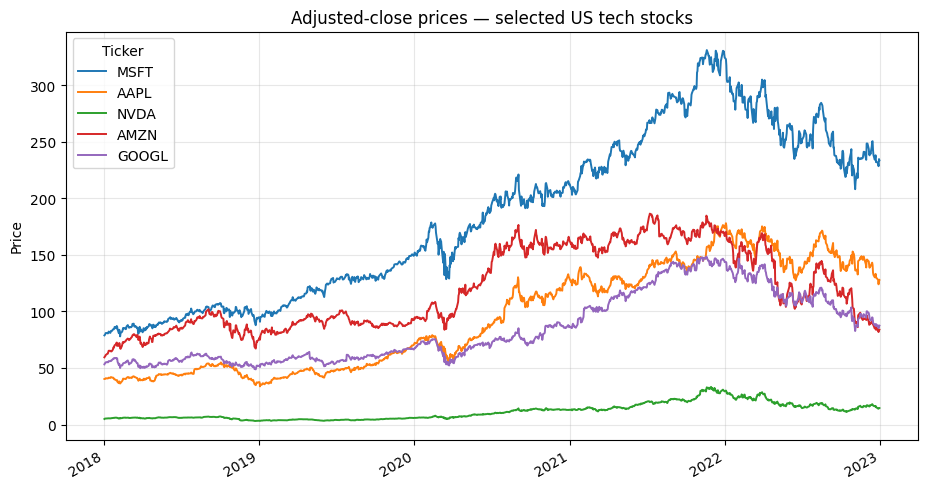

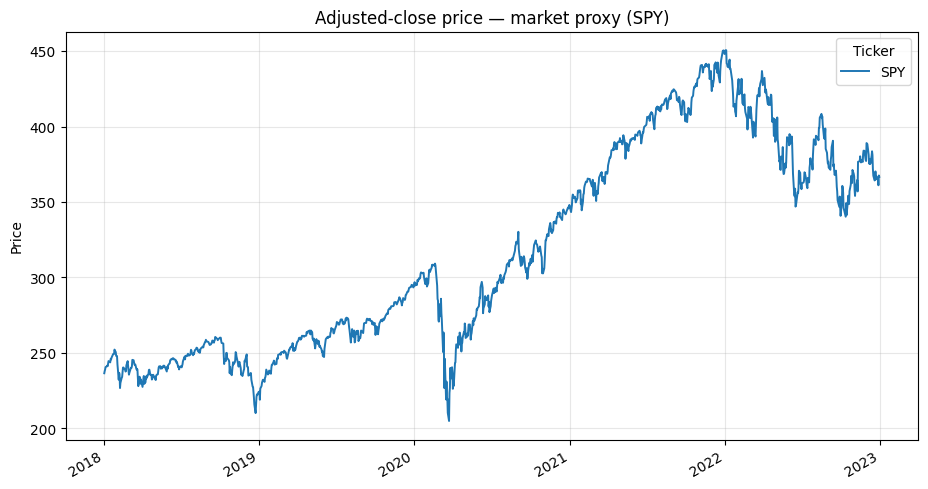

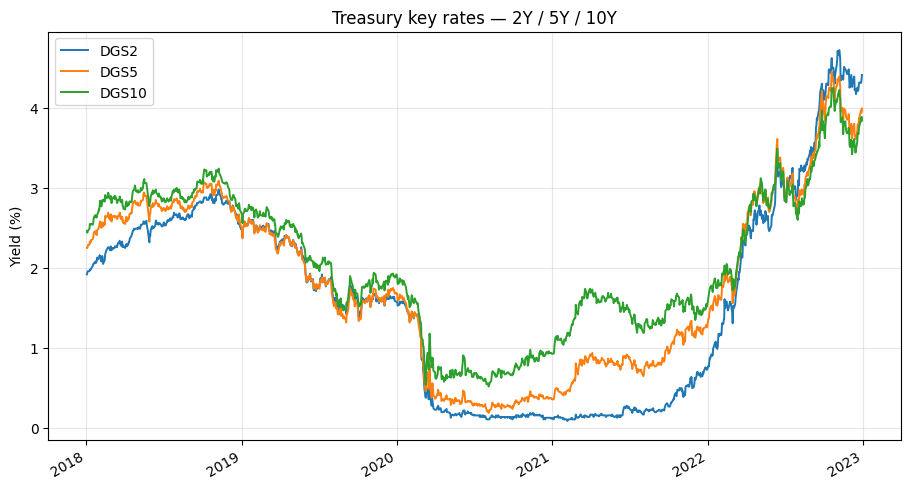

In [4]:

# Visual inspection of raw state variables
plot_time_series(stock_prices, "Adjusted-close prices — selected US tech stocks", "Price")
plot_time_series(market_proxy_prices, f"Adjusted-close price — market proxy ({MARKET_PROXY})", "Price")
plot_time_series(key_rates * 100.0, "Treasury key rates — 2Y / 5Y / 10Y", "Yield (%)")


## 2. Risk-driver design

### Equity block — upgraded to an explicit ERP proxy
The equity block is now built in two variants:

1. **Primary block**: an observed **market ERP proxy** based on the excess log-return of **SPY**;  
2. **Challenger block**: the previous **latent tech-basket factor** extracted from the selected names.

For the active engine we use:
- stock excess log-returns,
- a common observed ERP proxy factor,
- a **low-dimensional residual factor block** obtained by PCA on regression residuals.

### Rates block — upgraded with interpretable geometry
The rates generator still uses PCA on daily key-rate changes for compact simulation, but we now also build **level / slope / curvature** diagnostics to interpret the risk-free term-structure block in economic terms.


In [5]:

# Build transformed risk drivers and upgraded factor blocks
equity_log_returns = compute_equity_log_returns(stock_prices)
yield_changes = compute_yield_changes(key_rates)
market_log_returns = compute_equity_log_returns(market_proxy_prices)

common_dates = equity_log_returns.index.intersection(yield_changes.index).intersection(market_log_returns.index)
equity_log_returns = equity_log_returns.loc[common_dates]
yield_changes = yield_changes.loc[common_dates]
key_rates = key_rates.loc[common_dates]
market_proxy_prices = market_proxy_prices.loc[common_dates]

latent_equity_block = build_latent_equity_premium_block(
    log_returns=equity_log_returns,
    short_rate_annualized=key_rates["DGS2"],
    resid_explained_var_target=TARGET_RESID_EXPLAINED_VAR,
)

proxy_equity_block = build_proxy_erp_equity_block(
    log_returns=equity_log_returns,
    market_proxy_prices=market_proxy_prices,
    short_rate_annualized=key_rates["DGS2"],
    resid_explained_var_target=TARGET_RESID_EXPLAINED_VAR,
)

# Active equity block used by the engine
equity_block = proxy_equity_block

rates_block = build_rates_factor_model(
    yield_changes=yield_changes,
    explained_var_target=TARGET_RATE_EXPLAINED_VAR,
)

curve_lsc_levels = build_curve_lsc_factors(key_rates)
curve_lsc_changes = curve_lsc_levels.diff().dropna()

print(f"Active equity factor block: {equity_block['factor_label']}")
print(f"Latent-tech factor explained variance: {latent_equity_block['explained_variance']:.3f}")
print(f"Residual equity factors retained     : {equity_block['resid_scores'].shape[1]}")
print(f"Rates factors retained               : {rates_block['n_factors']}")


Active equity factor block: market_erp_proxy_factor
Latent-tech factor explained variance: 0.768
Residual equity factors retained     : 4
Rates factors retained               : 3


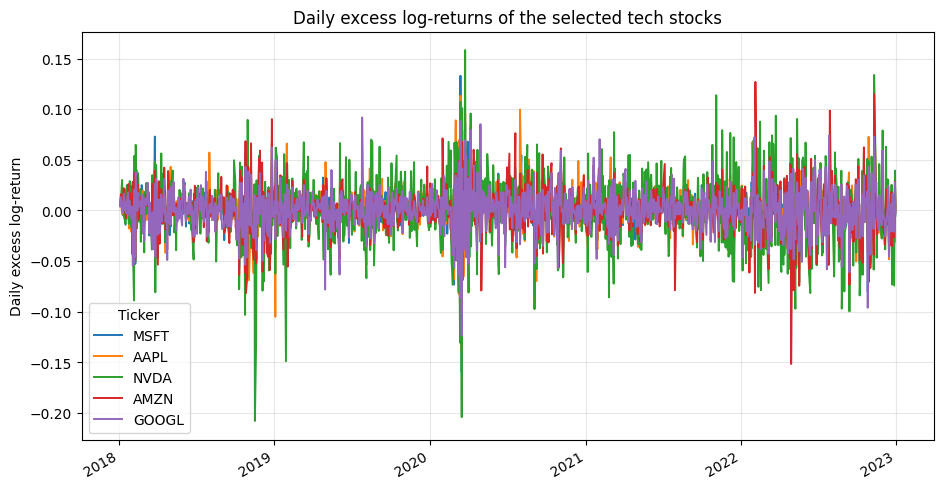

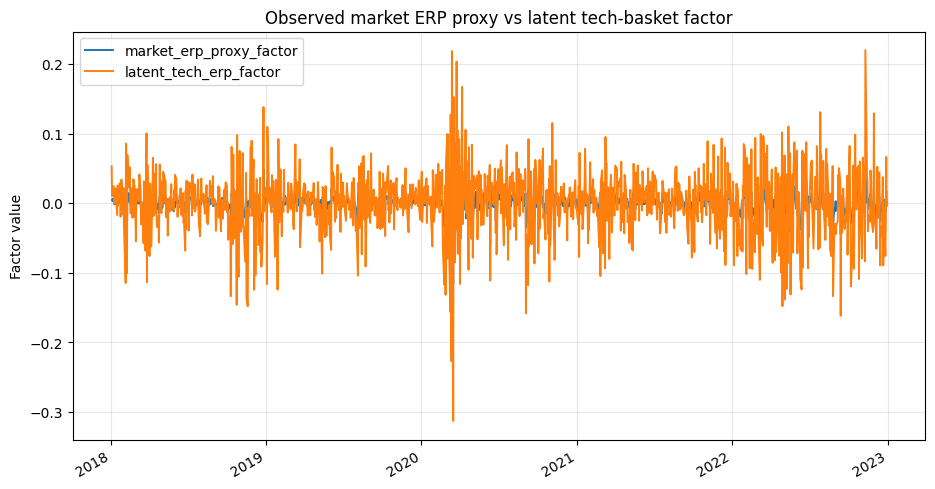

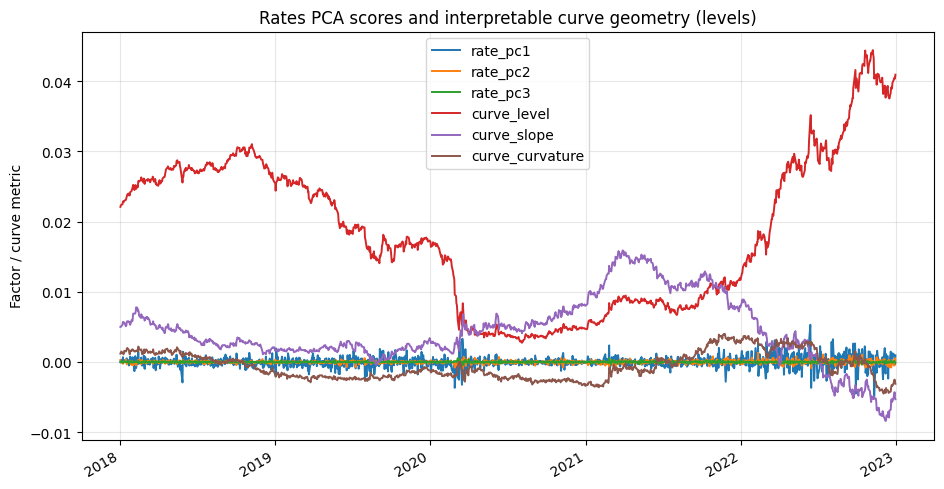

In [6]:

# Plot core transformed drivers
plot_time_series(
    equity_block["excess_returns"],
    "Daily excess log-returns of the selected tech stocks",
    "Daily excess log-return",
)

plot_time_series(
    pd.concat(
        [
            proxy_equity_block["factor"].rename("market_erp_proxy_factor"),
            latent_equity_block["factor"].rename("latent_tech_erp_factor"),
        ],
        axis=1,
    ),
    "Observed market ERP proxy vs latent tech-basket factor",
    "Factor value",
)

plot_time_series(
    pd.concat([rates_block["scores"], curve_lsc_levels], axis=1),
    "Rates PCA scores and interpretable curve geometry (levels)",
    "Factor / curve metric",
)


In [7]:

# Diagnostics on factorization quality and interpretability
equity_resid_corr = equity_block["residuals"].corr()
driver_corr = pd.concat(
    [equity_block["factor"], equity_block["resid_scores"], rates_block["scores"]],
    axis=1
).corr()

factor_compare = pd.concat(
    [
        proxy_equity_block["factor"].rename("market_erp_proxy_factor"),
        latent_equity_block["factor"].rename("latent_tech_erp_factor"),
    ],
    axis=1,
).corr()

rate_interpretation = pd.concat([rates_block["scores"], curve_lsc_changes], axis=1).dropna().corr()
rate_interpretation = rate_interpretation.loc[rates_block["scores"].columns, curve_lsc_changes.columns]

active_equity_betas = equity_block["betas"].to_frame("beta_to_active_erp_factor")

print("Active equity block betas:")
display(active_equity_betas)

print("Residual equity correlation matrix:")
display(equity_resid_corr)

print("Residual equity PCA explained variance:")
display(equity_block["resid_explained_ratio"].to_frame("resid_explained_variance_ratio"))
display(equity_block["resid_cum_explained_ratio"].to_frame("resid_cum_explained_ratio"))

print("Correlation between observed ERP proxy and latent tech factor:")
display(factor_compare)

print("Driver correlation matrix for the active engine:")
display(driver_corr)

print("Economic interpretation of rates PCA scores via level / slope / curvature changes:")
display(rate_interpretation)


Active equity block betas:


,beta_to_active_erp_factor
MSFT,1.226535
AAPL,1.242539
NVDA,1.750849
AMZN,1.116038
GOOGL,1.161456


Residual equity correlation matrix:


Ticker,MSFT,AAPL,NVDA,AMZN,GOOGL
Ticker,,,,,
MSFT,1.000000,0.287078,0.280183,0.363321,0.410075
AAPL,0.287078,1.000000,0.203152,0.252412,0.172018
NVDA,0.280183,0.203152,1.000000,0.311705,0.226502
AMZN,0.363321,0.252412,0.311705,1.000000,0.329521
GOOGL,0.410075,0.172018,0.226502,0.329521,1.000000


Residual equity PCA explained variance:


...

,market_erp_proxy_factor,latent_tech_erp_factor
market_erp_proxy_factor,1.000000,0.863834
latent_tech_erp_factor,0.863834,1.000000


Driver correlation matrix for the active engine:


,market_erp_proxy_factor,resid_pc1,resid_pc2,resid_pc3,resid_pc4,rate_pc1,rate_pc2,rate_pc3
market_erp_proxy_factor,1.000000,-0.000000,-0.000000,-0.000000,0.000000,0.149741,-0.107862,-0.133809
resid_pc1,-0.000000,1.000000,-0.000000,0.000000,0.000000,-0.089301,0.122289,0.032414
resid_pc2,-0.000000,-0.000000,1.000000,0.000000,0.000000,-0.062466,0.011358,-0.009009
resid_pc3,-0.000000,0.000000,0.000000,1.000000,-0.000000,0.046252,0.079676,0.009507
resid_pc4,0.000000,0.000000,0.000000,-0.000000,1.000000,-0.008501,-0.000343,-0.023997
rate_pc1,0.149741,-0.089301,-0.062466,0.046252,-0.008501,1.000000,0.000000,-0.000000
rate_pc2,-0.107862,0.122289,0.011358,0.079676,-0.000343,0.000000,1.000000,-0.000000
rate_pc3,-0.133809,0.032414,-0.009009,0.009507,-0.023997,-0.000000,-0.000000,1.000000


Economic interpretation of rates PCA scores via level / slope / curvature changes:


,curve_level,curve_slope,curve_curvature
rate_pc1,0.999809,0.206955,0.416998
rate_pc2,0.018752,-0.978056,-0.131372
rate_pc3,-0.005682,-0.023427,0.899387


## 3. Joint state representation and hybrid scenario engine

The active joint driver vector now stacks:
- **1 observed market ERP proxy factor**,
- a **low-dimensional residual equity block**,
- the retained **rates PCA scores**.

A compact **VAR(1)** is fitted to the joint state.  
To reduce over-reliance on Gaussian innovations, the forecast step still uses a **stationary bootstrap** on historical VAR residuals.

The simulation is upgraded in one more important way:
- the **risk-free short-rate proxy is no longer frozen** at its initial value;
- instead, the simulated **2Y Treasury yield** updates the short-rate path day by day across the horizon.

So the engine is:

\[
X_{t+1} = c + A X_t +
arepsilon_{t+1}, \qquad
arepsilon_{t+1} 	ext{ resampled via stationary bootstrap,}
\]

with a pathwise mapping from simulated rate shocks to both:
- the horizon curve for bond repricing,
- the short-rate path used to convert excess returns into total returns.


In [8]:

# Joint state vector
drivers = build_joint_driver_matrix(equity_block, rates_block)
display(drivers.head())
print(f"Joint driver matrix shape: {drivers.shape}")
print("Driver columns:")
print(drivers.columns.tolist())


,market_erp_proxy_factor,resid_pc1,resid_pc2,resid_pc3,resid_pc4,rate_pc1,rate_pc2,rate_pc3
2018-01-04,0.003847,-0.001790,0.001304,-0.000222,0.000673,0.000320,0.000014,-0.000015
2018-01-05,0.006282,0.003029,0.011203,0.000096,0.001958,0.000158,-0.000074,0.000112
2018-01-08,0.001467,0.026559,-0.006641,-0.012674,-0.001213,0.000094,-0.000137,-0.000093
2018-01-09,0.001900,-0.004994,0.001136,-0.005175,-0.003511,0.000682,-0.000245,-0.000049
2018-01-10,-0.001892,0.009504,-0.003736,-0.001744,-0.003098,-0.000087,-0.000007,-0.000076


Joint driver matrix shape: (1247, 8)
Driver columns:
['market_erp_proxy_factor', 'resid_pc1', 'resid_pc2', 'resid_pc3', 'resid_pc4', 'rate_pc1', 'rate_pc2', 'rate_pc3']


In [9]:

# Fit the dynamic model
var_res = build_var1_model(drivers)

print("VAR(1) fitted successfully.")
print(f"Selected lag order: {var_res.k_ar}")
print(f"Number of state variables: {var_res.neqs}")
display(var_res.params)

try:
    print(var_res.summary())
except Exception as err:
    print("VAR summary could not be rendered cleanly.")
    print(f"Reason: {type(err).__name__}: {err}")

print("Companion roots:")
print(var_res.roots)


VAR(1) fitted successfully.
Selected lag order: 1
Number of state variables: 8


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,market_erp_proxy_factor,resid_pc1,resid_pc2,resid_pc3,resid_pc4,rate_pc1,rate_pc2,rate_pc3
const,-0.000004,0.000002,-0.000001,0.000001,0.000000,-0.000000,-0.000000,0.000000
L1.market_erp_proxy_factor,-0.154336,-0.166293,0.032689,-0.066422,-0.072027,-0.004151,0.001353,0.000262
L1.resid_pc1,0.041165,0.008675,0.032675,0.023849,0.003915,0.000370,0.000302,0.000208
L1.resid_pc2,-0.036721,0.028709,0.030225,-0.002178,-0.004965,-0.002754,0.000314,-0.000167
L1.resid_pc3,-0.075187,-0.008494,0.066498,0.057226,-0.018055,-0.003564,0.000479,0.000199
L1.resid_pc4,-0.002337,-0.159235,0.123573,-0.033449,0.003336,0.001567,0.000526,0.000430
L1.rate_pc1,-0.939559,0.230697,0.252002,0.231958,0.856360,0.023330,-0.017057,-0.002370
L1.rate_pc2,-1.917237,-3.815598,-0.703558,0.737121,0.100461,0.148447,-0.011408,0.022197
L1.rate_pc3,-1.721494,-9.610093,1.600227,-1.234949,-0.379925,-0.047491,0.127016,-0.124638


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 13, Apr, 2026
Time:                     13:25:12
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -91.2232
Nobs:                     1246.00    HQIC:                  -91.4081
Log likelihood:           42944.7    FPE:                1.79295e-40
AIC:                     -91.5195    Det(Omega_mle):     1.69263e-40
--------------------------------------------------------------------
Results for equation market_erp_proxy_factor
                                coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------------
const                             -0.000004         0.000381           -0.010           0.992
L1.market_erp_proxy_factor        -0.154336         0.028605           -5.395       

In [10]:

# Simulate one-week scenarios under the upgraded hybrid factor engine
current_prices = stock_prices.loc[effective_date]
current_key_rates = key_rates.loc[effective_date]

sim = simulate_joint_horizon(
    var_res=var_res,
    resid_hist=var_res.resid,
    last_state=drivers.iloc[-1].to_numpy(),
    equity_block=equity_block,
    rates_block=rates_block,
    current_prices=current_prices,
    current_key_rates=current_key_rates,
    horizon_bdays=HORIZON_BDAYS,
    n_scenarios=N_SCENARIOS,
    avg_block_length=BOOTSTRAP_EXPECTED_BLOCK,
    rng_seed=RNG_SEED,
)

stock_excess_return_scenarios = sim["stock_excess_return_scenarios"]
stock_log_return_scenarios = sim["stock_log_return_scenarios"]
stock_price_scenarios = sim["stock_price_scenarios"]
key_rate_scenarios = sim["key_rate_scenarios"]


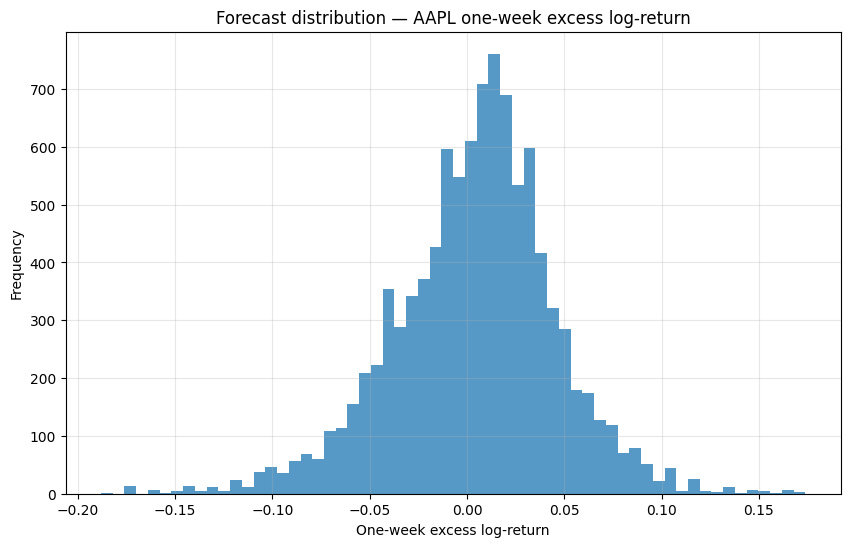

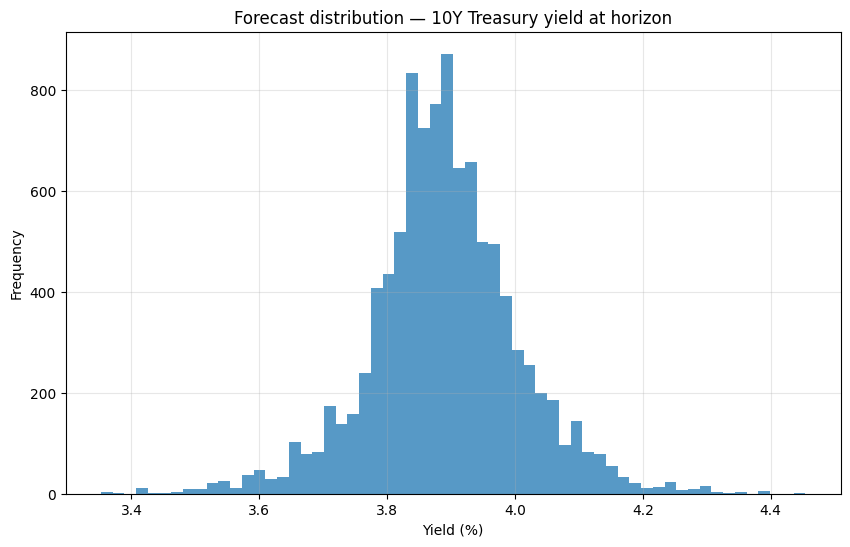

,AAPL_1w_excess_return
mean,0.003815
std,0.041998
q01,-0.108298
q05,-0.067943
median,0.007275
q95,0.068335
q99,0.102390
VaR_95_loss,0.067943
ES_95_loss,0.094505


,DGS10_horizon_yield
mean,0.038894
std,0.001171
q01,0.035730
q05,0.036981
median,0.038866
q95,0.040890
q99,0.041933
min,0.033522
max,0.044543


In [11]:
# Marginal forecast views
plot_histogram(
    stock_excess_return_scenarios["AAPL"],
    "Forecast distribution — AAPL one-week excess log-return",
    "One-week excess log-return",
)

plot_histogram(
    key_rate_scenarios["DGS10"] * 100.0,
    "Forecast distribution — 10Y Treasury yield at horizon",
    "Yield (%)",
)

display(loss_summary_from_pnl(stock_excess_return_scenarios["AAPL"]).to_frame("AAPL_1w_excess_return"))
display(distribution_summary(key_rate_scenarios["DGS10"]).to_frame("DGS10_horizon_yield"))

## 4. Lightweight scenario validation

This is still not a full model-validation notebook, but a few checks are now more informative because the engine has a stronger internal structure.

We compare:
- simulated one-week stock return dispersion,
- simulated one-week yield-change dispersion,
- and the implied horizon distribution of the 2Y yield itself,

against rolling historical 5-business-day aggregates from the estimation sample.


In [12]:

# Historical 5-day benchmarks for rough validation
hist_5d_stock = rolling_horizon_log_returns(equity_log_returns, HORIZON_BDAYS)
hist_5d_yield = rolling_horizon_yield_changes(yield_changes, HORIZON_BDAYS)

validation_table = pd.DataFrame({
    "hist_5d_std_AAPL": [hist_5d_stock["AAPL"].std()],
    "sim_1w_std_AAPL": [stock_log_return_scenarios["AAPL"].std()],
    "hist_5d_std_DGS10_change": [hist_5d_yield["DGS10"].std()],
    "sim_1w_std_DGS10_change": [(key_rate_scenarios["DGS10"] - current_key_rates["DGS10"]).std()],
    "current_DGS2": [current_key_rates["DGS2"]],
    "sim_mean_DGS2": [key_rate_scenarios["DGS2"].mean()],
    "sim_std_DGS2": [key_rate_scenarios["DGS2"].std()],
})

display(validation_table.T.rename(columns={0: "value"}))


,value
hist_5d_std_AAPL,0.042819
sim_1w_std_AAPL,0.041998
hist_5d_std_DGS10_change,0.001153
sim_1w_std_DGS10_change,0.001171
current_DGS2,0.044100
sim_mean_DGS2,0.044185
sim_std_DGS2,0.001063


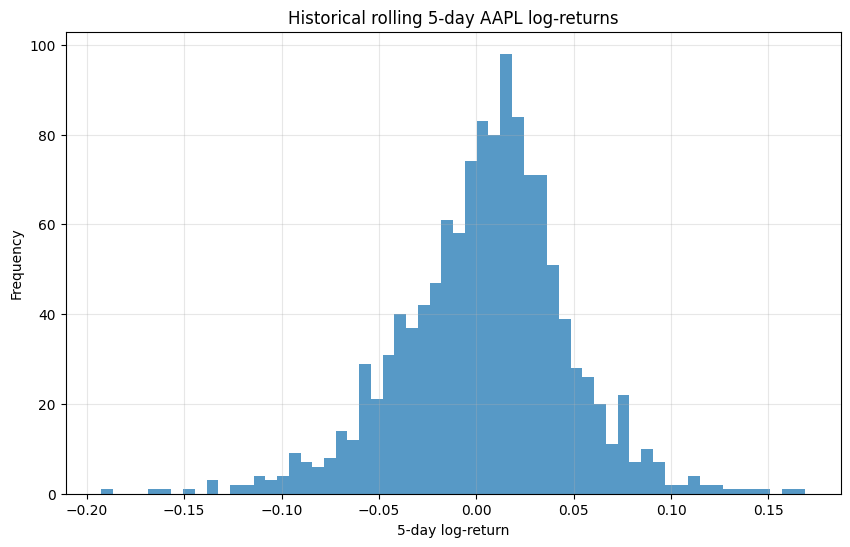

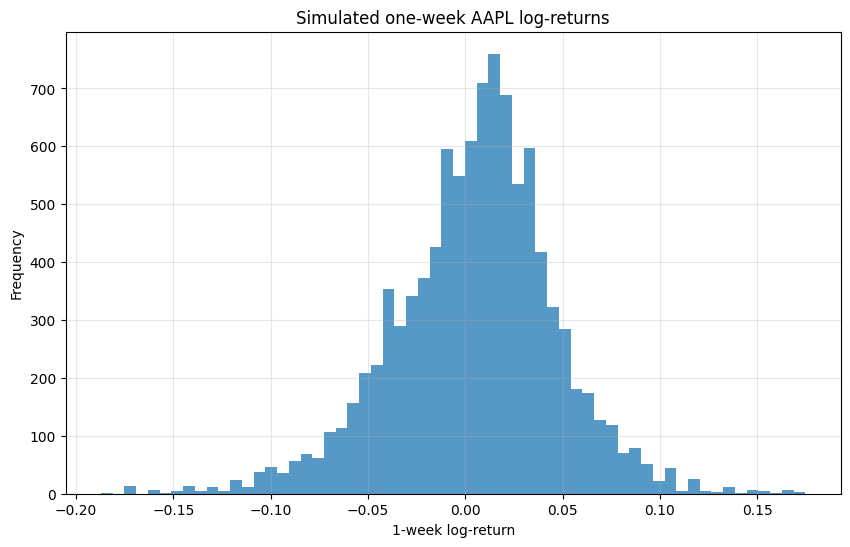

In [13]:

# Visual comparison: historical rolling 5d vs simulated 1w
plot_histogram(hist_5d_stock["AAPL"], "Historical rolling 5-day AAPL log-returns", "5-day log-return")
plot_histogram(stock_log_return_scenarios["AAPL"], "Simulated one-week AAPL log-returns", "1-week log-return")

## 5. Horizon repricing

### Equities
Each stock is repriced directly from the simulated cumulative log-return over the horizon.

### Treasury note
We define a synthetic **10Y coupon-bearing Treasury note** at the effective date:
- coupon = 2%
- semiannual coupons
- repricing at the 5-business-day horizon uses the **scenario-specific key-rate curve**.

The curve is still reconstructed by a simple piecewise-linear zero-rate interpolation from the simulated 2Y / 5Y / 10Y points.  
That remains intentionally light enough for a research notebook, while still preserving the essential bridge between:
- **rates scenario generation**,
- **discounting**,
- **instrument repricing**.


In [14]:

# Treasury note definition and current repricing
issue_date = pd.Timestamp(effective_date)
horizon_date = issue_date + BDay(HORIZON_BDAYS)
maturity_date = issue_date + pd.DateOffset(years=10)

coupon_schedule = generate_coupon_schedule(issue_date, maturity_date, freq=PAY_FREQ)

current_bond_price = price_coupon_bond_from_curve(
    eval_date=issue_date,
    payment_dates=coupon_schedule,
    key_rate_series=current_key_rates,
    coupon_rate=COUPON_RATE,
    face_value=FACE_VALUE,
    freq=PAY_FREQ,
)

print(f"Synthetic Treasury note current price: {current_bond_price:,.4f}")
print(f"Issue date   : {issue_date.date()}")
print(f"Horizon date : {pd.Timestamp(horizon_date).date()}")
print(f"Maturity date: {maturity_date.date()}")

Synthetic Treasury note current price: 84.1532
Issue date   : 2022-12-30
Horizon date : 2023-01-06
Maturity date: 2032-12-30


In [15]:
# Scenario-wise horizon repricing of the bond
bond_horizon_prices = key_rate_scenarios.apply(
    lambda row: price_coupon_bond_from_curve(
        eval_date=horizon_date,
        payment_dates=coupon_schedule,
        key_rate_series=row,
        coupon_rate=COUPON_RATE,
        face_value=FACE_VALUE,
        freq=PAY_FREQ,
    ),
    axis=1,
)
bond_horizon_prices.name = "UST_10Y_2pct"

bond_pnl = bond_horizon_prices - current_bond_price

display(distribution_summary(bond_horizon_prices).to_frame("UST_10Y_2pct_horizon_value"))
display(loss_summary_from_pnl(bond_pnl).to_frame("UST_10Y_2pct_one_week_pnl"))

,UST_10Y_2pct_horizon_value
mean,84.146586
std,0.880089
q01,81.873705
q05,82.672261
median,84.160762
q95,85.570082
q99,86.627534
min,80.027410
max,88.253061


,UST_10Y_2pct_one_week_pnl
mean,-0.006656
std,0.880089
q01,-2.279536
q05,-1.480981
median,0.007520
q95,1.416841
q99,2.474292
VaR_95_loss,1.480981
ES_95_loss,1.962890


In [16]:
# Joint instrument values, P&L, and capital-normalized returns at horizon
instrument_horizon_values = stock_price_scenarios.copy()
instrument_horizon_values["UST_10Y_2pct"] = bond_horizon_prices

current_values = current_prices.copy()
current_values["UST_10Y_2pct"] = current_bond_price

instrument_pnl = instrument_horizon_values.sub(current_values, axis=1)
instrument_returns = instrument_pnl.div(current_values, axis=1)

instrument_value_table = instrument_horizon_values.describe().T
instrument_pnl_table = instrument_pnl.describe().T
instrument_return_loss_table = pd.DataFrame({
    col: loss_summary_from_pnl(instrument_returns[col], alpha=CVAR_ALPHA)
    for col in instrument_returns.columns
}).T

print("Horizon values:")
display(instrument_value_table)

print("Instrument-level one-week P&L:")
display(instrument_pnl_table)

print("Capital-normalized one-week return/loss metrics:")
display(instrument_return_loss_table)

Horizon values:


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
MSFT,"10,000.000000",234.928897,8.292967,193.000854,230.216164,235.762511,239.839808,271.292750
AAPL,"10,000.000000",128.593477,5.370946,106.051746,125.410324,128.925230,131.875626,152.297827
NVDA,"10,000.000000",14.692328,1.004810,9.879567,14.112060,14.723218,15.335054,19.146423
AMZN,"10,000.000000",84.095009,4.179751,67.106640,81.859099,84.174330,86.460055,102.908967
GOOGL,"10,000.000000",87.833152,3.349662,73.342085,85.873741,88.063016,89.861995,102.068034
UST_10Y_2pct,"10,000.000000",84.146586,0.880089,80.027410,83.648095,84.160762,84.608423,88.253061


Instrument-level one-week P&L:


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
MSFT,"10,000.000000",1.242190,8.292967,-40.685853,-3.470542,2.075805,6.153102,37.606043
AAPL,"10,000.000000",0.714174,5.370946,-21.827557,-2.468979,1.045927,3.996323,24.418524
NVDA,"10,000.000000",0.093733,1.004810,-4.719029,-0.486536,0.124623,0.736459,4.547827
AMZN,"10,000.000000",0.095009,4.179751,-16.893360,-2.140901,0.174330,2.460055,18.908967
GOOGL,"10,000.000000",0.326385,3.349662,-14.164682,-1.633027,0.556249,2.355228,14.561267
UST_10Y_2pct,"10,000.000000",-0.006656,0.880089,-4.125832,-0.505146,0.007520,0.455182,4.099819


Capital-normalized one-week return/loss metrics:


,mean,std,q01,q05,median,q95,q99,VaR_95_loss,ES_95_loss
MSFT,0.005316,0.035488,-0.093940,-0.058134,0.008883,0.057906,0.088637,0.058134,0.079747
AAPL,0.005585,0.042000,-0.101822,-0.064869,0.008179,0.071660,0.108790,0.064869,0.088903
NVDA,0.006421,0.068829,-0.181356,-0.114261,0.008537,0.114729,0.168211,0.114261,0.154113
AMZN,0.001131,0.049759,-0.134001,-0.083992,0.002075,0.080757,0.124483,0.083992,0.115195
GOOGL,0.003730,0.038279,-0.098023,-0.063242,0.006357,0.063889,0.097663,0.063242,0.084034
UST_10Y_2pct,-0.000079,0.010458,-0.027088,-0.017599,0.000089,0.016836,0.029402,0.017599,0.023325


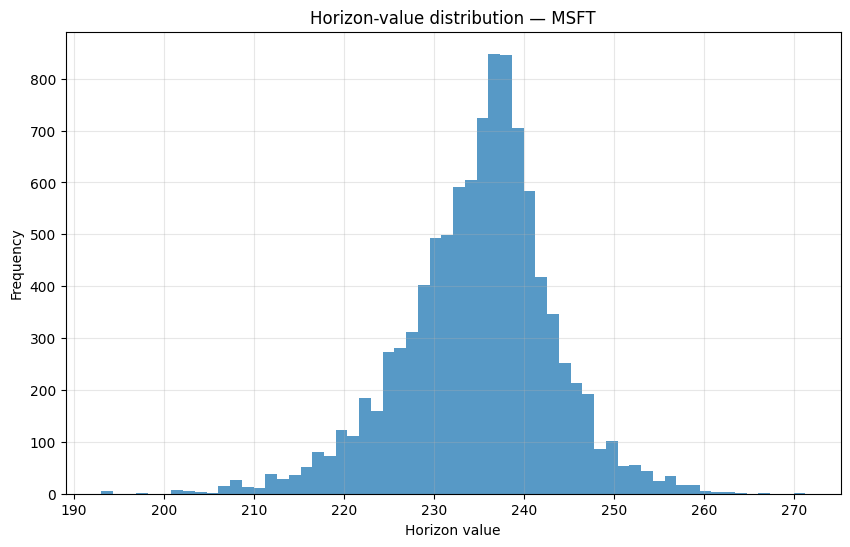

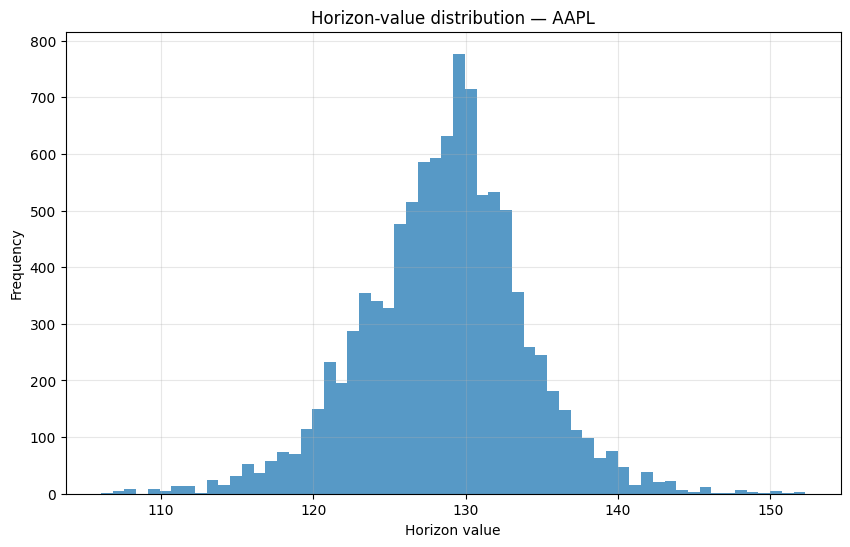

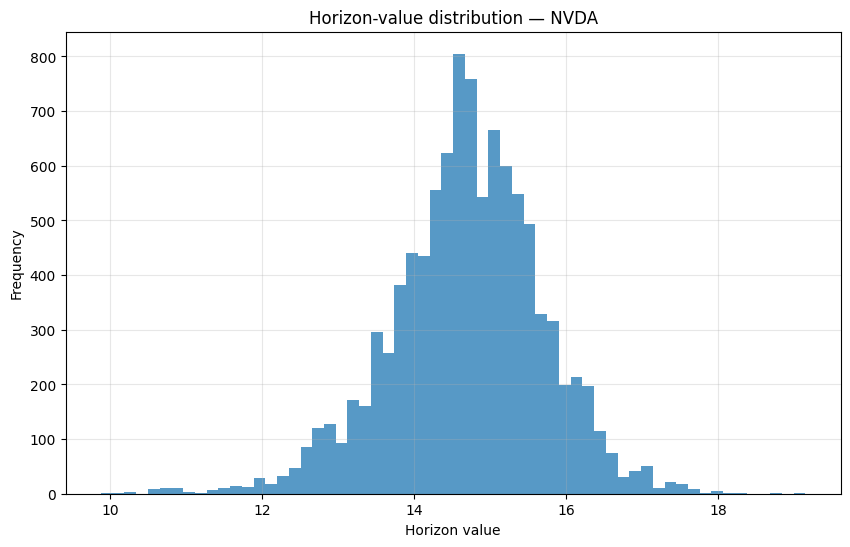

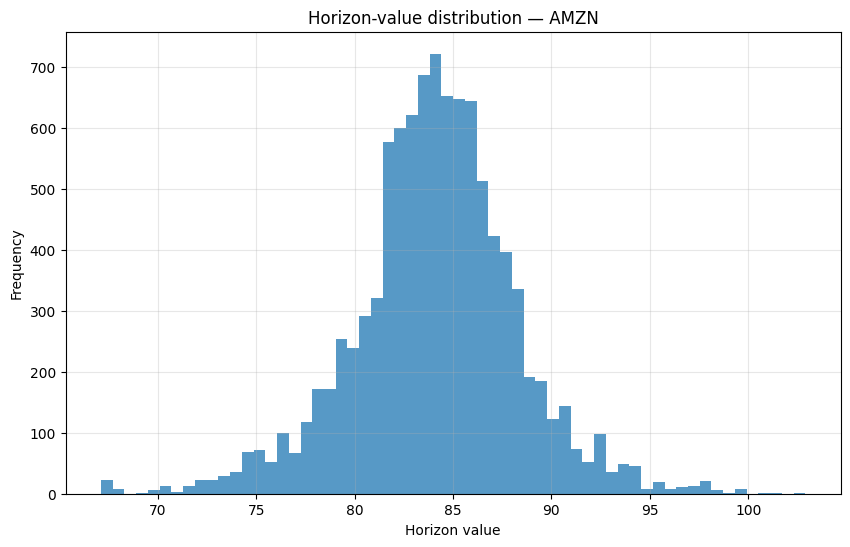

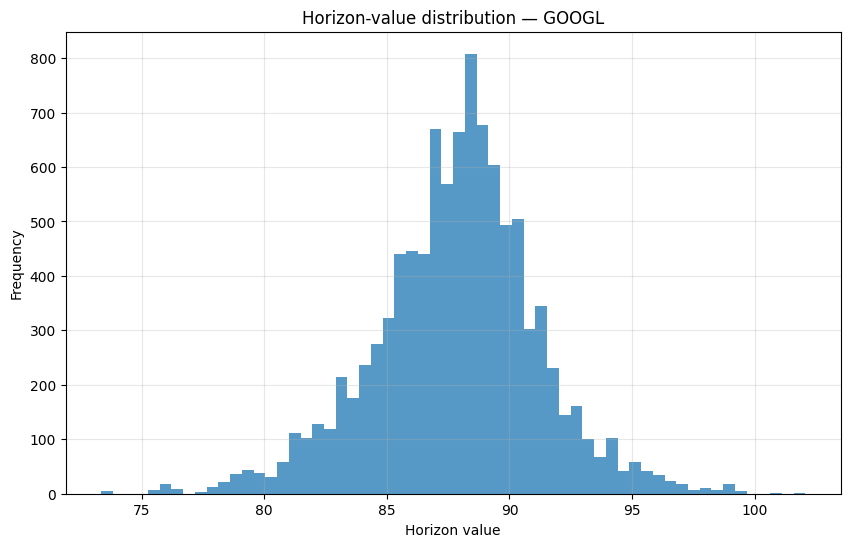

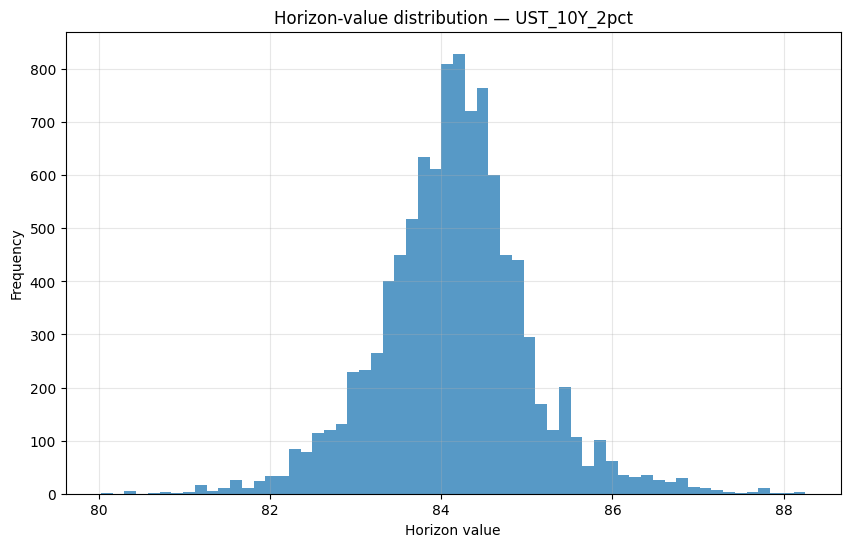

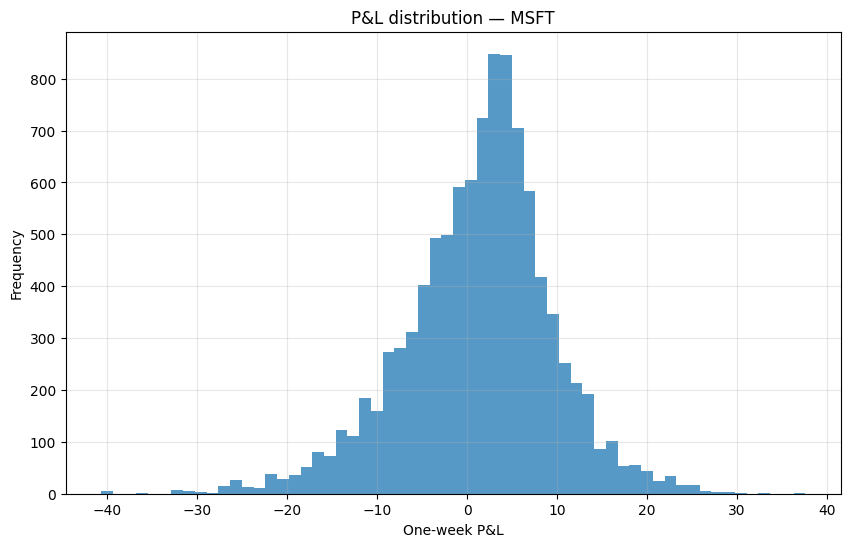

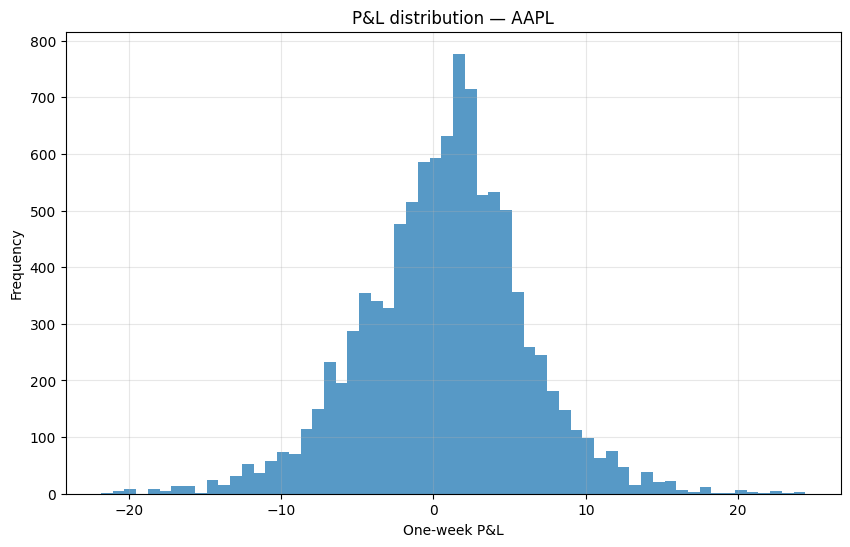

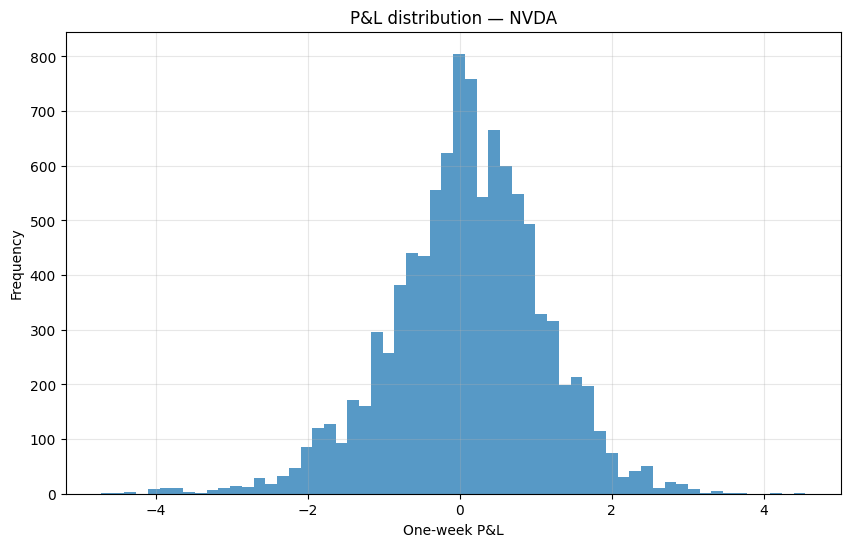

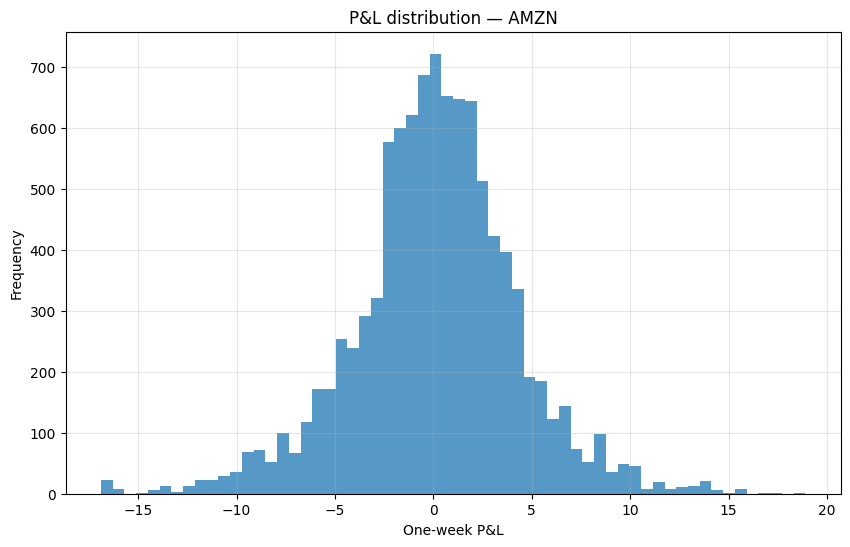

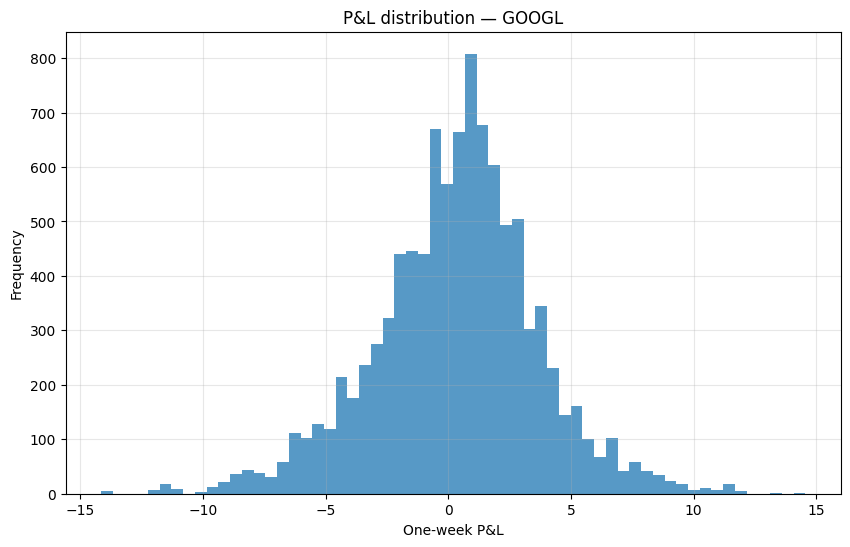

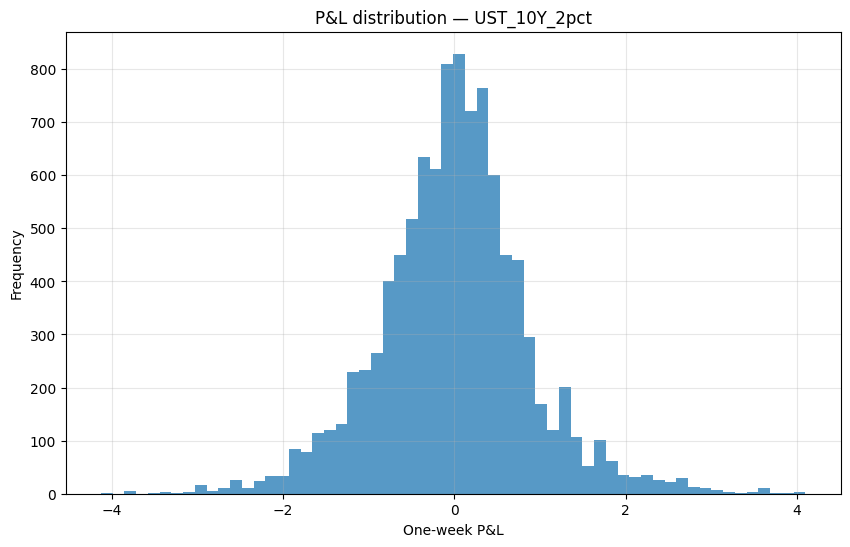

In [17]:

# Instrument-level visualizations
for col in instrument_horizon_values.columns:
    plot_histogram(
        instrument_horizon_values[col],
        f"Horizon-value distribution — {col}",
        "Horizon value",
    )

for col in instrument_pnl.columns:
    plot_histogram(
        instrument_pnl[col],
        f"P&L distribution — {col}",
        "One-week P&L",
    )

## 6. Portfolio robustness layer — fixed in capital-normalized return space

The portfolio layer is now evaluated on **capital-normalized one-week instrument returns**, not on raw per-unit instrument P&Ls.
This makes cross-asset weights economically interpretable: a 20% weight in the bond and a 20% weight in NVDA now both mean **20% of portfolio capital**.

Three fixes are applied here:

1. **Portfolio comparison and minimum-CVaR search are run on one-week simple returns** (P&L divided by initial instrument value);
2. **Tail contributions are computed using weighted asset contributions**, so they add up to the portfolio tail loss;
3. **VaR/ES are reported only on genuine loss variables** (portfolio return / P&L style quantities), not on levels such as yields or prices.


In [18]:
# Candidate portfolio weights in capital-normalized return space
all_assets = instrument_returns.columns.tolist()
equity_assets = TICKERS.copy()

equal_weight = pd.Series(1.0 / len(all_assets), index=all_assets)
equity_only = pd.Series(0.0, index=all_assets)
equity_only.loc[equity_assets] = 1.0 / len(equity_assets)

bond_heavy = pd.Series(0.10, index=all_assets)
bond_heavy["UST_10Y_2pct"] = 0.50

inverse_vol = inverse_vol_weights_from_scenarios(instrument_returns)
min_cvar_long_only, min_cvar_info = search_long_only_min_cvar_portfolio(
    instrument_returns=instrument_returns,
    n_draws=CVAR_SEARCH_DRAWS,
    alpha=CVAR_ALPHA,
    seed=RNG_SEED,
    max_weight=CVAR_MAX_WEIGHT,
    chunk_size=CVAR_SEARCH_CHUNK,
)

portfolio_weights = {
    "equal_weight": equal_weight,
    "equity_only": equity_only,
    "bond_heavy": bond_heavy,
    "inverse_vol": inverse_vol,
    "min_cvar_long_only": min_cvar_long_only,
}

portfolio_returns = {}
portfolio_metrics = {}
for name, w in portfolio_weights.items():
    port_ret, metrics = portfolio_metrics_from_instrument_returns(w, instrument_returns, alpha=CVAR_ALPHA)
    portfolio_returns[name] = port_ret
    portfolio_metrics[name] = metrics

weights_table = pd.DataFrame(portfolio_weights).T
metrics_table = pd.DataFrame(portfolio_metrics).T.sort_values("ES_95_loss")

print("Long-only min-CVaR search diagnostics:")
display(min_cvar_info.to_frame("value"))

print("Portfolio weights:")
display(weights_table)

print("Portfolio one-week return/loss metrics:")
display(metrics_table)

Long-only min-CVaR search diagnostics:


,value
n_valid_draws,"11,626.000000"
VaR_95_loss,0.025676
ES_95_loss,0.035545
mean,0.001725
std,0.015521


Portfolio weights:


,MSFT,AAPL,NVDA,AMZN,GOOGL,UST_10Y_2pct
equal_weight,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
equity_only,0.200000,0.200000,0.200000,0.200000,0.200000,0.000000
bond_heavy,0.100000,0.100000,0.100000,0.100000,0.100000,0.500000
inverse_vol,0.135243,0.114272,0.069730,0.096454,0.125381,0.458919
min_cvar_long_only,0.148629,0.059362,0.035479,0.022058,0.107291,0.627182


Portfolio one-week return/loss metrics:


,mean,std,q01,q05,median,q95,q99,VaR_95_loss,ES_95_loss,mean_abs_weight
min_cvar_long_only,0.001725,0.015521,-0.041028,-0.025676,0.003021,0.024011,0.038911,0.025676,0.035545,0.166667
bond_heavy,0.002179,0.021137,-0.055929,-0.037226,0.003816,0.034165,0.053173,0.037226,0.047598,0.166667
inverse_vol,0.002345,0.021625,-0.057454,-0.037905,0.004020,0.034992,0.053947,0.037905,0.048643,0.166667
equal_weight,0.003684,0.033949,-0.086547,-0.058481,0.006585,0.055750,0.083452,0.058481,0.076907,0.166667
equity_only,0.004436,0.040616,-0.104526,-0.069405,0.008024,0.066890,0.100501,0.069405,0.092126,0.166667


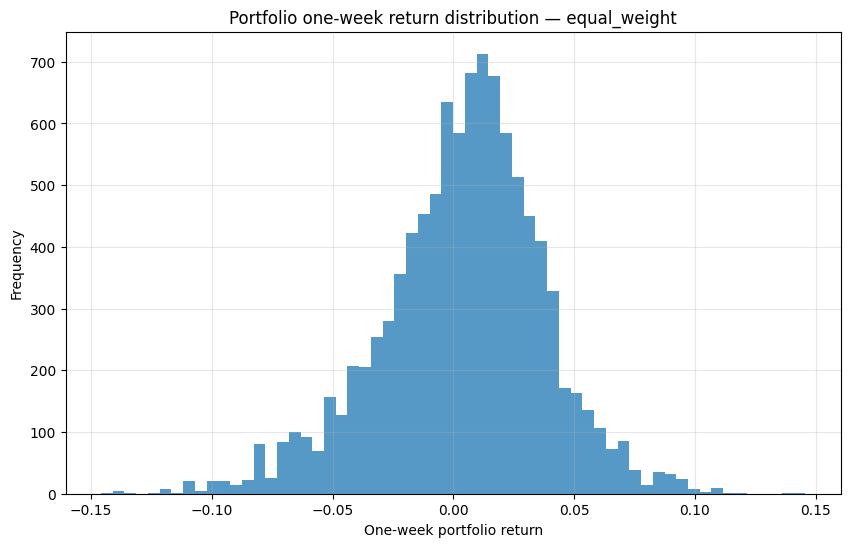

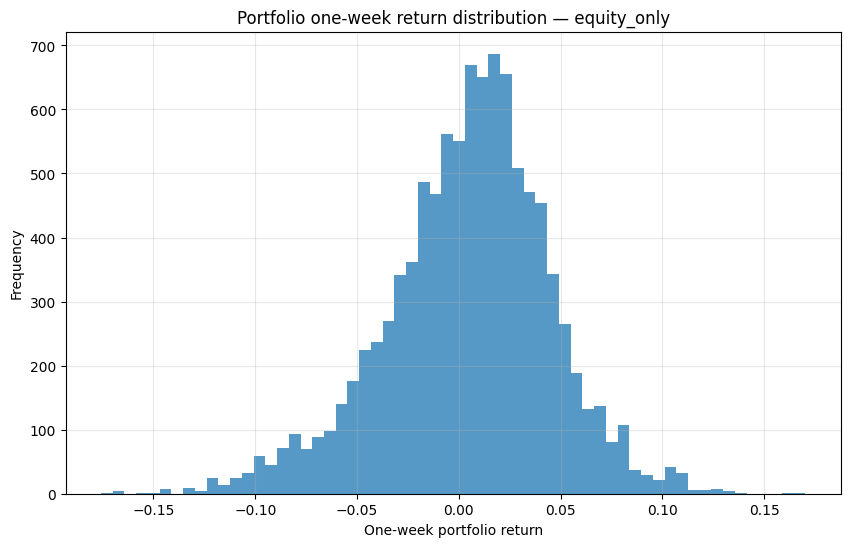

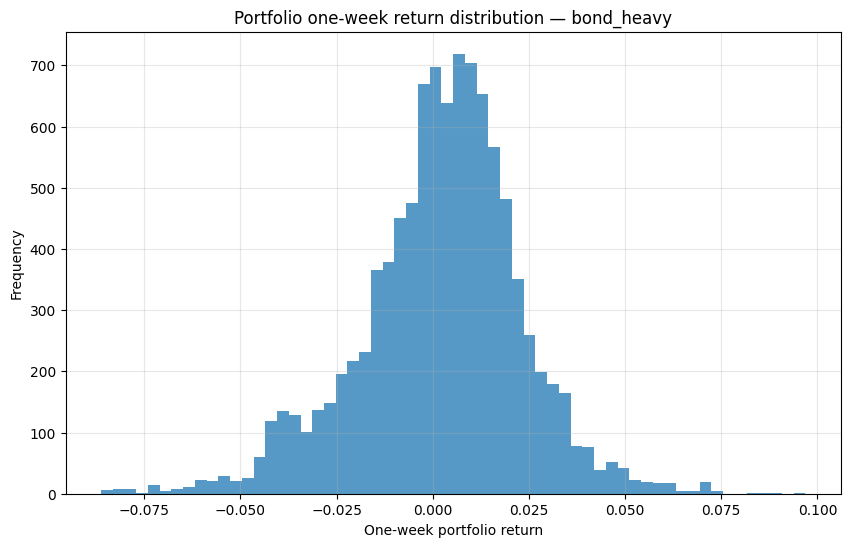

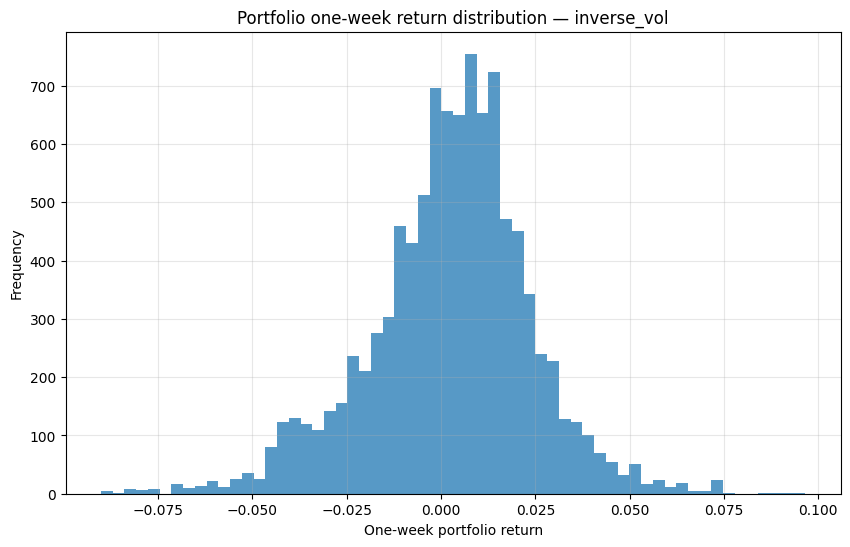

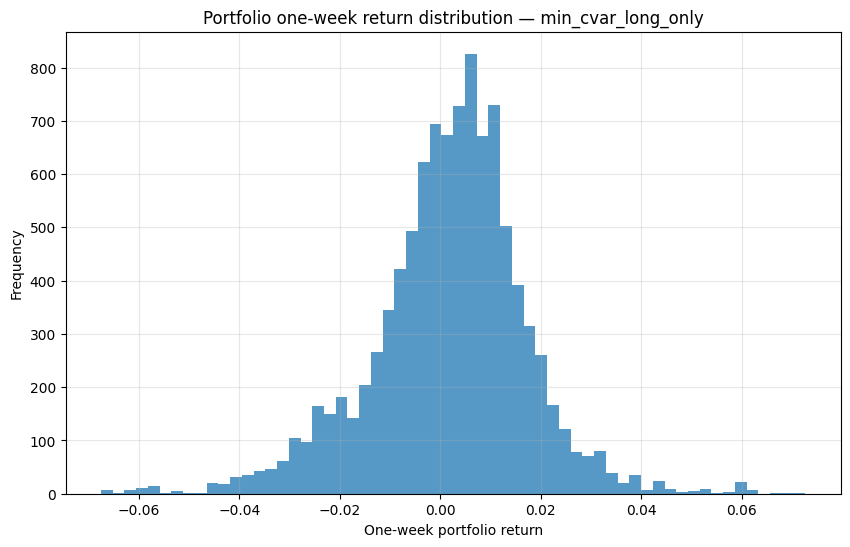

In [19]:
# Portfolio-level distributions
for name, port_ret in portfolio_returns.items():
    plot_histogram(
        port_ret,
        f"Portfolio one-week return distribution — {name}",
        "One-week portfolio return",
    )

In [20]:
# Weighted tail contributions for the min-CVaR portfolio
tail_table = tail_contribution_table(
    portfolio_return=portfolio_returns["min_cvar_long_only"],
    instrument_returns=instrument_returns,
    weights=portfolio_weights["min_cvar_long_only"],
    alpha=CVAR_ALPHA,
)
display(tail_table)

,weight,avg_tail_return_contribution,avg_tail_loss_contribution,share_of_portfolio_ES_loss
Ticker,,,,
MSFT,0.148629,-0.010248,0.010248,0.288297
UST_10Y_2pct,0.627182,-0.008413,0.008413,0.236696
GOOGL,0.107291,-0.007477,0.007477,0.210342
NVDA,0.035479,-0.003834,0.003834,0.107860
AAPL,0.059362,-0.003816,0.003816,0.107370
AMZN,0.022058,-0.001757,0.001757,0.049435


## 7. What is reusable from here?

This notebook now contains the skeleton of a much broader project.

### Reusable now
- data loading and cross-asset alignment,
- **observed ERP-proxy equity block**,
- **latent tech-factor challenger block**,
- low-dimensional residual equity factor compression,
- risk-free curve factor generator,
- interpretable **level / slope / curvature** diagnostics,
- joint VAR + stationary-bootstrap scenario engine,
- pathwise short-rate propagation,
- horizon repricer,
- portfolio robustness layer,
- heuristic long-only minimum-CVaR portfolio search.

### Natural next upgrades
1. **Risk-free generator upgrade**
   - richer term-structure input beyond 2Y / 5Y / 10Y,
   - rolling recalibration,
   - alternative dynamics (e.g., explicit level / slope / curvature state instead of PCA scores).
2. **Equity-premium generator upgrade**
   - compare SPY vs QQQ vs sector / factor proxies,
   - add regime conditioning or time-varying beta structure,
   - introduce macro or volatility-state covariates.
3. **Validation upgrade**
   - rolling backtests,
   - predictive score comparison across engine variants,
   - tail calibration diagnostics.
4. **Portfolio construction upgrade**
   - constrained optimisation,
   - robust mean-CVaR frontiers,
   - scenario-conditioned allocation rules.


## Final takeaway

The resulting object is best described as a:

> **modular multi-asset scenario engine under the physical measure for joint equity-rates scenario generation, horizon repricing, and portfolio tail-risk analysis, combining an observed ERP proxy, residual factor compression, rates factor modelling, VAR dynamics, stationary-bootstrap innovations, and full instrument-level repricing.**

That is no longer a course notebook in any meaningful sense. It is already a credible **research / GitHub building block** for market-risk quant, risk-strat, and cross-asset analytics narratives.
